# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 8. XAI (SHAP 분석)

**목표**
- 최종 모델(LightGBM 튜닝 + CalibratedClassifierCV Isotonic) 재학습 및 저장
- 해석용 LightGBM(보정 없음)을 별도로 전체 데이터로 학습하여 SHAP TreeExplainer 적용
- SHAP 기반 전역/개별 해석으로 모델 의사결정 근거 확인 및 운영 액션 도출

**운영용 vs 해석용 모델 분리**
- 운영용: CalibratedClassifierCV 보정 모델 (day8_calibrated_lgbm.pkl)
- 해석용: 동일 하이퍼파라미터 LightGBM 전체 데이터 재학습 → SHAP TreeExplainer 적용
- SHAP의 목적은 보정 자체가 아닌 "모델이 왜 그렇게 예측했는지"를 설명하는 것이므로 분리가 적절함

**SHAP 분석 계획**
- 전역 해석용: 불균형 보정 층화 샘플링 20,000건 (사기 3,000건 + 정상 17,000건)
- 사례 설명용: 사기 50건 + 정상 50건

**진행 순서**
1. 데이터 + 변수 세트 불러오기 + LightGBM best params 로드
2. 타겟 인코딩 함수 재정의
3. 운영용 보정 모델 학습 및 저장 (CalibratedClassifierCV)
4. 해석용 LightGBM 학습 및 저장 (SHAP 전용, early stopping 적용)
5. 불균형 보정 층화 샘플링
6. SHAP TreeExplainer 생성 및 SHAP 값 계산
7. Summary Plot (Bar) — 상위 변수 10개 중요도
8. Summary Plot (Beeswarm) — 상위 변수 분포와 방향성
9. Waterfall Plot — 사기 2건 + 정상 2건 개별 사례 분석
10. SHAP 결과 기반 운영 액션 도출

**최종 산출물**
- day8_calibrated_lgbm.pkl (운영용 모델)
- day8_shap_model.pkl (해석용 모델)
- day8_shap_values.pkl (SHAP 값)
- day8_shap_bar.png / day8_shap_beeswarm.png / day8_waterfall_*.png

# SHAP(Shapley Additive exPlanations) — 개념 정리

- 정의: SHAP는 Shapley value(협동 게임 이론)를 기반으로, 모델의 한 예측치에 대해 각 피처(feature)가 예측에 기여한 **정량적 값(Shap값)** 을 계산해 주는 방법이다. [web:12]

- 핵심 아이디어: 각 피처를 "플레이어"로 보고, 가능한 모든 피처 조합(연합)에 대해 해당 피처를 추가했을 때 예측(또는 가치)이 얼마나 변하는지를 계산한 후, 그 모든 한계 기여도의 가중 평균을 취해 해당 피처의 기여도를 산출한다. 

- 수학적 성질(중요 4가지):
  - Efficiency: 모든 피처의 SHAP 값을 더하면(합산하면) 모델의 예측값과 기준(평균 예측값 또는 베이스라인)과의 차이가 된다. 
  - Symmetry: 두 피처가 같은 기여를 한다면 동일한 SHAP 값을 가진다. 
  - Dummy: 어떤 피처가 예측에 영향을 주지 않으면 SHAP 값은 0이다. 
  - Additivity: 서로 다른 모델의 결합에 대해 SHAP 값이 선형적으로 합쳐진다. 

- 구현/추정:
  - 모든 조합을 계산하면 조합 수가 2^p로 폭증하므로, 실무에선 Monte‑Carlo 샘플링(근사)이나 모델 특화 알고리즘(TreeSHAP 등)을 사용해 계산 비용을 줄인다. 

- 장점:
  - 이론적 근거가 탄탄하고 공정성 공리(위 4가지)를 만족해 해석 결과가 직관적이다. 
  - 전역(global) 설명(특성 중요도)과 지역(local) 설명(관측치별 기여) 모두 제공할 수 있다. 

- 단점/주의점:
  - 피처 간 상호작용이나 상관관계가 강한 경우 해석이 모호해질 수 있고, 계산 비용(특히 변수 수가 많은 경우)이 매우 높다. 
  - SHAP 값은 인과관계를 증명하지 않으며, 단지 ‘예측에 기여한 정도’를 보여준다.

- 실무 팁:
  - 트리 기반 모델은 TreeSHAP를 사용하면 빠르게 계산할 수 있다.
  - 피처 전처리(카테고리 인코딩, 결측 처리) 방식이 SHAP 값에 영향을 주므로 전처리 정책을 문서화하라. 
  - 개별 관측치의 SHAP 설명을 집단별(예: 불량/정상)으로 집계하면 모델의 편향이나 드리프트 포인트를 찾기 쉽다. 

- 해석 예시(직관):  
  어떤 고객의 대출 ‘부실 확률 0.35’가 전체 평균 0.10에 비해 +0.25 높은 경우, 각 피처의 SHAP 값을 더하면 이 +0.25가 설명된다(예: 연령 +0.02, 연체횟수 +0.18, 신용한도 −0.05 등). 

- 참고: Lundberg & Lee(2017)의 원리와 TreeSHAP/KernelSHAP 같은 구현을 보면 구체적 알고리즘과 최적화 방법을 확인할 수 있다. 

### LightGBM은 **트리 기반 모델**입니다. 

정확히는 결정트리(Decision Tree)를 여러 개 결합한 **Gradient Boosting Decision Tree(GBDT)** 계열이고, 트리를 **leaf-wise** 방식으로 자라게 하는 것이 특징입니다.

핵심만 정리하면:

- **Decision Tree 기반**이다. 
- 여러 트리를 순차적으로 학습하는 **부스팅 앙상블**이다. 
- 일반적인 level-wise 대신 **leaf-wise 트리 성장 방식**을 사용한다. 

-> 그래서 SHAP 같은 해석 기법에서 LightGBM은 보통 **TreeSHAP** 적용 대상으로 자주 다뤄집니다. 

### 1. 라이브러리 임포트 및 데이터 불러오기

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import sys
sys.path.append("..")

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
import shap

pd.set_option('display.max_columns', 100)

df = pd.read_parquet("../data/processed/day3_final.parquet")

with open("../data/processed/day6_tuning_results.pkl", 'rb') as f:
    tuning_results = pickle.load(f)

best_params_lgbm = tuning_results['best_params']['LightGBM']

exclude_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'UID', 'UID_v2']
target = 'isFraud'
groups = df['UID']

categorical_cols = df.drop(columns=exclude_cols).select_dtypes(include='category').columns.tolist()
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()
binary_cols = [c for c in numeric_cols if df[c].nunique() <= 2]
scale_cols = [c for c in numeric_cols if c not in binary_cols]

X = df.drop(columns=exclude_cols + [target])
y = df[target]
imbalance_ratio = (y == 0).sum() / (y == 1).sum()

print(f"shape: {df.shape}")
print(f"LightGBM best params: {best_params_lgbm}")
print(f"클래스 불균형 비율: 1:{imbalance_ratio:.1f}")

c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shape: (590540, 208)
LightGBM best params: {'learning_rate': 0.1563037874293778, 'num_leaves': 165, 'min_child_samples': 32, 'subsample': 0.9248534606596772, 'colsample_bytree': 0.6651160762107319, 'reg_lambda': 0.00025077983643406634}
클래스 불균형 비율: 1:27.6


### 2. 타겟 인코딩 함수 재정의

커널 재부팅으로 인해 이전 노트북의 함수가 사라졌으므로 재정의합니다.

In [3]:
def target_encode(train_df, valid_df, cols, target_col, smoothing=20):
    global_mean = train_df[target_col].mean()
    encoded_train = train_df.copy()
    encoded_valid = valid_df.copy()
    for col in cols:
        encoded_train[col] = encoded_train[col].astype(str)
        encoded_valid[col] = encoded_valid[col].astype(str)
        stats = train_df.assign(**{col: train_df[col].astype(str)}).groupby(col)[target_col].agg(['mean', 'count'])
        smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        encoded_train[col] = encoded_train[col].map(smoothed).fillna(global_mean)
        encoded_valid[col] = encoded_valid[col].map(smoothed).fillna(global_mean)
    return encoded_train, encoded_valid

print("함수 정의 완료")

함수 정의 완료


### 3. 보정된 LightGBM 전체 데이터로 재학습

SHAP 분석을 위해 전체 데이터(59만 건)로 최종 모델을 학습합니다.
Day 7에서 모델 객체 저장이 누락되어 재학습이 필요합니다.
학습 완료 후 모델 객체를 pkl로 저장하여 이후 노트북에서 재사용합니다.

**주의**: CalibratedClassifierCV는 내부적으로 CV를 돌리므로 시간이 오래 걸릴 수 있습니다.

In [4]:
import warnings
warnings.filterwarnings('ignore')

# 전처리: 타겟 인코딩 + 표준화 (전체 데이터 기준)
X_full = X.copy()

# 타겟 인코딩 (전체 데이터 기준, 누수 주의: SHAP용이므로 허용)
temp_full = pd.concat([X_full[categorical_cols], y], axis=1)
_, X_full_enc = target_encode(temp_full, X_full[categorical_cols].copy(), categorical_cols, target)
X_full[categorical_cols] = X_full_enc[categorical_cols].values.astype(float)

# 표준화
scaler = StandardScaler()
X_full[scale_cols] = scaler.fit_transform(X_full[scale_cols])

# 보정된 LightGBM 정의 및 학습
model_lgbm = LGBMClassifier(
    **best_params_lgbm,
    n_estimators=5000,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    verbosity=-1,
)

calibrated_lgbm = CalibratedClassifierCV(model_lgbm, method='isotonic', cv=5)
calibrated_lgbm.fit(X_full, y)
print("모델 학습 완료")

# 모델 객체 저장 (이후 재사용)
with open("../data/processed/day8_calibrated_lgbm.pkl", 'wb') as f:
    pickle.dump({
        'model': calibrated_lgbm,
        'scaler': scaler,
        'X_full': X_full,
    }, f)

print("모델 객체 저장 완료: day8_calibrated_lgbm.pkl")

모델 학습 완료
모델 객체 저장 완료: day8_calibrated_lgbm.pkl


### 4. SHAP 층화 샘플링

전체 59만 건 중 SHAP 분석용 샘플을 추출합니다.

사기 비율이 3.5%로 낮아 무작위 샘플링 시 사기 사례가 너무 적게 포함될 수 있으므로,
사기/정상 비율을 보정한 층화 샘플링을 적용합니다.

**샘플링 방식: 불균형 보정 층화 샘플링**
- 비례 층화 샘플링(원본 비율 3.5% 유지)을 쓰면 2만 건 중 사기가 700건에 불과하여
  "사기 거래에서 어떤 변수가 중요한가"를 제대로 파악하기 어려움
- 따라서 사기 비율을 의도적으로 높여(15%) 사기 패턴 해석의 신뢰성을 확보함

**샘플 구성**
- 전역 해석용: 총 20,000건 (사기 3,000건(15%) + 정상 17,000건(85%))
- 사례 설명용: 사기 50건 + 정상 50건 (별도 추출)

In [5]:
np.random.seed(42)

fraud_idx   = np.where(y == 1)[0]
normal_idx  = np.where(y == 0)[0]

# 전역 해석용 샘플
n_fraud_global  = 3000
n_normal_global = 17000
global_idx = np.concatenate([
    np.random.choice(fraud_idx,  n_fraud_global,  replace=False),
    np.random.choice(normal_idx, n_normal_global, replace=False)
])
np.random.shuffle(global_idx)

X_shap_global = X_full.iloc[global_idx]
y_shap_global = y.iloc[global_idx]

# 사례 설명용 샘플
n_case = 50
case_idx = np.concatenate([
    np.random.choice(fraud_idx,  n_case, replace=False),
    np.random.choice(normal_idx, n_case, replace=False)
])
X_shap_case = X_full.iloc[case_idx]
y_shap_case = y.iloc[case_idx]

print(f"전역 해석용: {len(X_shap_global)}건 (사기 {y_shap_global.sum()}건, 정상 {(y_shap_global==0).sum()}건)")
print(f"사례 설명용: {len(X_shap_case)}건 (사기 {y_shap_case.sum()}건, 정상 {(y_shap_case==0).sum()}건)")

전역 해석용: 20000건 (사기 3000건, 정상 17000건)
사례 설명용: 100건 (사기 50건, 정상 50건)


### 5. 해석용 LightGBM 학습 (SHAP 전용)

**운영용 모델과 해석용 모델 분리**

| 구분 | 모델 | 용도 |
|---|---|---|
| 운영용 | CalibratedClassifierCV (day8_calibrated_lgbm.pkl) | 실제 사기 판단, threshold 적용 |
| 해석용 | 보정 없는 LightGBM (전체 데이터 재학습) | SHAP TreeExplainer 적용, 변수 중요도 해석 |

**해석용 모델을 별도로 학습하는 이유**
- CalibratedClassifierCV는 내부적으로 여러 fold의 모델과 보정 단계를 결합한 래퍼 구조라
  SHAP TreeExplainer가 직접 지원하지 않음
- SHAP의 목적은 "모델이 왜 그렇게 예측했는지"를 설명하는 것이지, 보정 자체를 설명하는 게 아님
- 동일한 하이퍼파라미터로 재학습한 LightGBM은 운영 모델과 동일한 학습 패턴을 가지므로
  해석 결과의 신뢰성이 유지됨

**해석용 모델 설정**
- 하이퍼파라미터: Day 6 Optuna 튜닝 best_params 동일 적용
- n_estimators=5000 + early_stopping_rounds=50
- 전체 데이터(59만 건) 학습

In [6]:
import lightgbm as lgb

# early stopping을 위해 전체 데이터의 10%를 검증용으로 분리
from sklearn.model_selection import train_test_split

X_train_shap, X_val_shap, y_train_shap, y_val_shap = train_test_split(
    X_full, y, test_size=0.1, random_state=42, stratify=y
)

shap_model = lgb.LGBMClassifier(
    **best_params_lgbm,
    n_estimators=5000,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    verbosity=-1,
)

shap_model.fit(
    X_train_shap, y_train_shap,
    eval_set=[(X_val_shap, y_val_shap)],
    eval_metric='average_precision',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

print(f"학습 완료 (best iteration: {shap_model.best_iteration_})")

# 해석용 모델 저장
with open("../data/processed/day8_shap_model.pkl", 'wb') as f:
    pickle.dump(shap_model, f)
print("해석용 모델 저장 완료: day8_shap_model.pkl")

학습 완료 (best iteration: 642)
해석용 모델 저장 완료: day8_shap_model.pkl


### 6. SHAP 값 계산

SHAP TreeExplainer를 사용하여 전역 해석용 샘플(20,000건)의 SHAP 값을 계산합니다.
TreeExplainer는 트리 기반 모델(LightGBM, XGBoost, RF 등)에 특화된 SHAP 계산 방식으로,
일반 KernelExplainer보다 훨씬 빠르고 정확해요.

계산 완료 후 pkl로 저장하여 시각화 단계에서 재사용합니다.

In [7]:
import shap

explainer = shap.TreeExplainer(shap_model)
shap_values_global = explainer.shap_values(X_shap_global)

# LightGBM 이진분류에서 shap_values는 [정상, 사기] 2개 반환
# 사기 클래스(index 1) 기준으로 사용
if isinstance(shap_values_global, list):
    shap_values_fraud = shap_values_global[1]
else:
    shap_values_fraud = shap_values_global

print(f"SHAP 값 계산 완료")
print(f"shap_values shape: {shap_values_fraud.shape}")

# 저장
with open("../data/processed/day8_shap_values.pkl", 'wb') as f:
    pickle.dump({
        'shap_values_fraud': shap_values_fraud,
        'X_shap_global': X_shap_global,
        'y_shap_global': y_shap_global,
        'X_shap_case': X_shap_case,
        'y_shap_case': y_shap_case,
        'feature_names': X_full.columns.tolist(),
    }, f)
print("SHAP 값 저장 완료: day8_shap_values.pkl")

SHAP 값 계산 완료
shap_values shape: (20000, 203)
SHAP 값 저장 완료: day8_shap_values.pkl


### 7. SHAP 시각화

**시각화 순서: 전체 → 패턴 → 사례**
1. Summary Plot (Bar): 상위 변수 10개 중요도 순위 (전체적으로 뭐가 중요한지)
2. Summary Plot (Beeswarm): 상위 변수 분포와 방향성 (변수값이 높을 때/낮을 때 예측이 어떻게 움직이는지)
3. Waterfall Plot: 사기 2건 + 정상 2건 개별 사례 분석 (이 거래가 왜 사기/정상으로 판단됐는지)

In [8]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

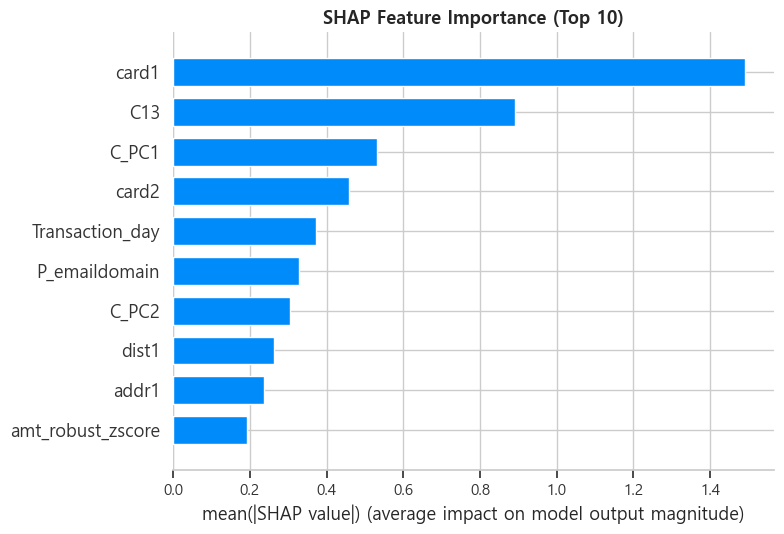

저장 완료: day8_shap_bar.png


In [9]:
import matplotlib.pyplot as plt
import shap

shap.summary_plot(
    shap_values_fraud,
    X_shap_global,
    plot_type='bar',
    max_display=10,
    show=False
)
plt.title('SHAP Feature Importance (Top 10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/day8_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: day8_shap_bar.png")

### 7-2. Summary Plot (Beeswarm)

변수값이 높을 때(빨강)/낮을 때(파랑) 사기 예측에 어떤 영향을 미치는지 방향성과 분포를 함께 확인합니다.

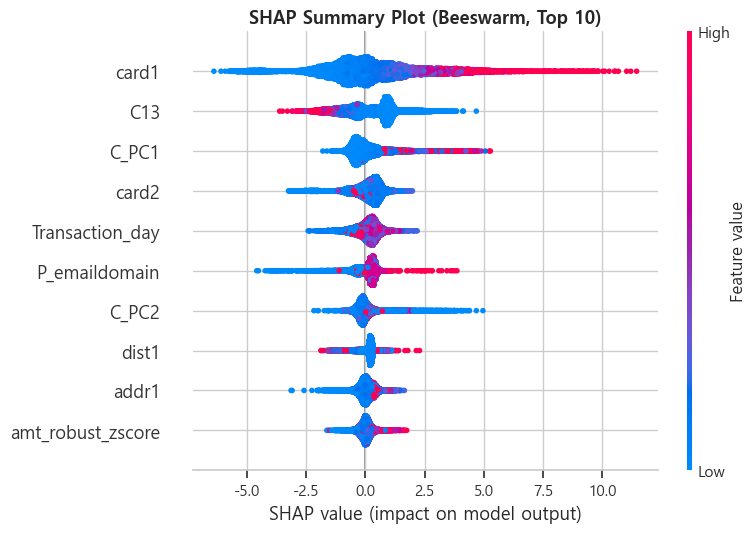

저장 완료: day8_shap_beeswarm.png


In [10]:
shap.summary_plot(
    shap_values_fraud,
    X_shap_global,
    plot_type='dot',
    max_display=10,
    show=False
)
plt.title('SHAP Summary Plot (Beeswarm, Top 10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/day8_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: day8_shap_beeswarm.png")

### 7-3. Waterfall Plot (개별 사례 분석)

사기 2건 + 정상 2건을 선택하여 각 거래가 왜 사기/정상으로 판단됐는지
변수별 기여도를 확인합니다.

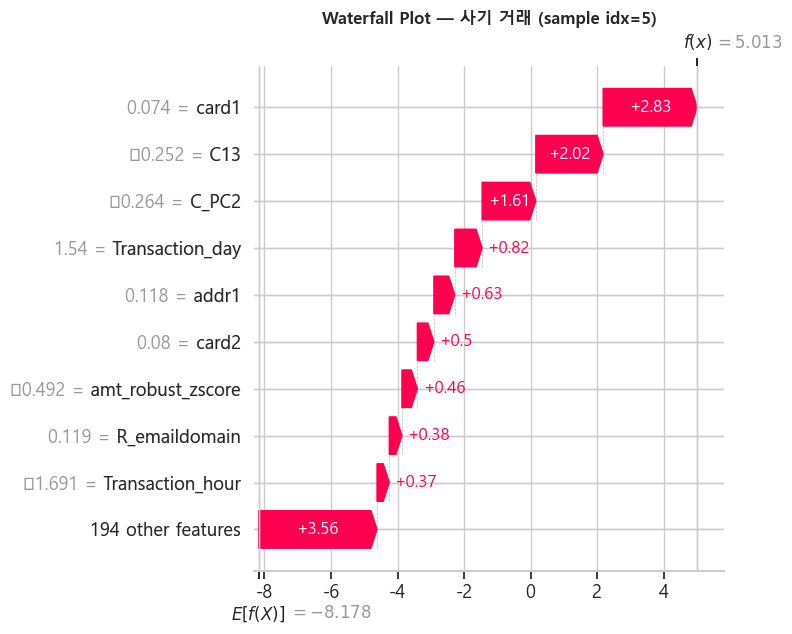

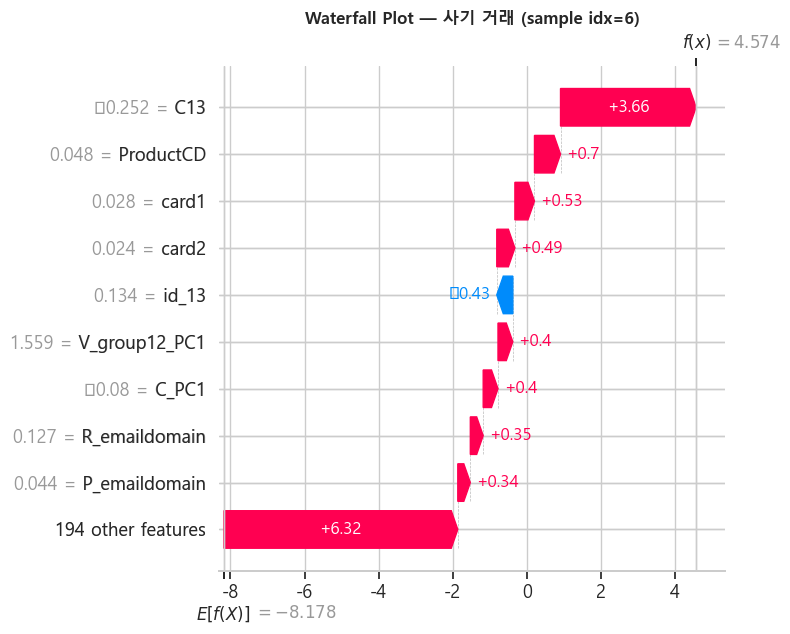

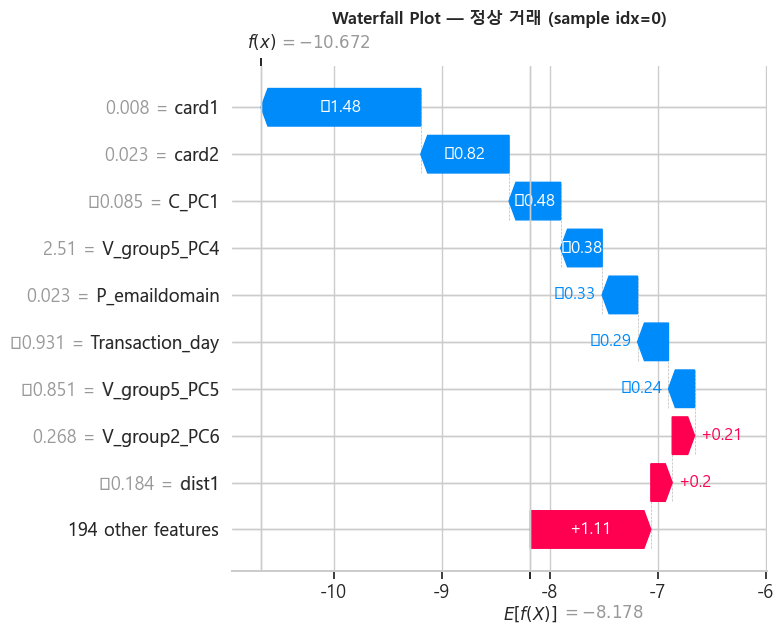

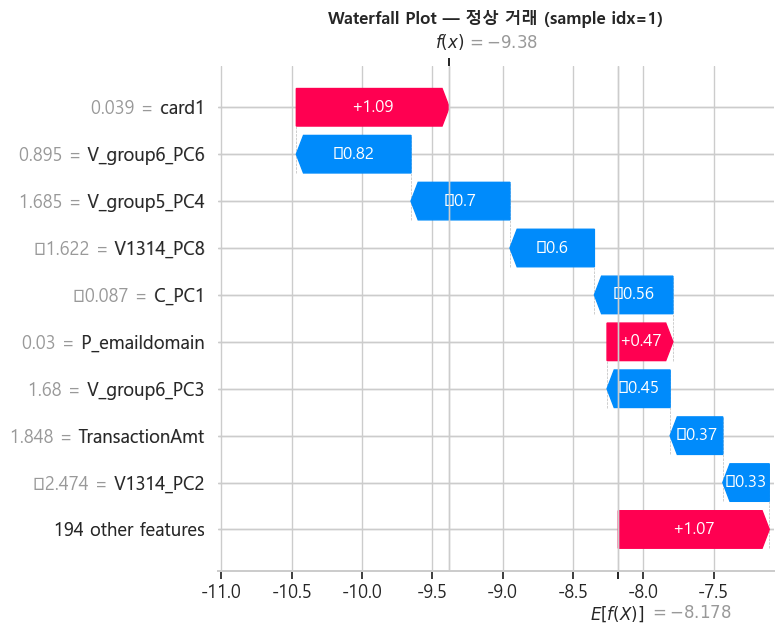

Waterfall Plot 저장 완료


In [11]:
# SHAP Explanation 객체 생성
explanation = shap.Explanation(
    values=shap_values_fraud,
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                else explainer.expected_value,
    data=X_shap_global.values,
    feature_names=X_shap_global.columns.tolist()
)

# 사기 샘플 인덱스 (y_shap_global 기준)
fraud_local_idx  = np.where(y_shap_global.values == 1)[0][:2]
normal_local_idx = np.where(y_shap_global.values == 0)[0][:2]

for idx in fraud_local_idx:
    plt.figure()
    shap.plots.waterfall(explanation[idx], max_display=10, show=False)
    plt.title(f'Waterfall Plot — 사기 거래 (sample idx={idx})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/day8_waterfall_fraud_{idx}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

for idx in normal_local_idx:
    plt.figure()
    shap.plots.waterfall(explanation[idx], max_display=10, show=False)
    plt.title(f'Waterfall Plot — 정상 거래 (sample idx={idx})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/day8_waterfall_normal_{idx}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print("Waterfall Plot 저장 완료")

**참고**: card1이 SHAP 중요도 1위로 나타난 것에 대해, 09_drift_analysis.ipynb에서
시간적 누수 여부와 스무딩 강도에 따른 과적합 여부를 추가로 검증했다. 결론적으로
card1의 SHAP 순위(1위) 자체는 견고하게 재현되나, 절대적 수치는 저빈도 카테고리의
잔여 과적합이 일부 반영되어 다소 과대추정된 값이다. 자세한 검증 과정은 09 노트북
8-8~8-9절 참조.

### 8. SHAP 시각화 결과 해석

---

#### 8-1. Summary Plot (Bar) — 전체 변수 중요도

**card1이 압도적 1위(1.5)**로 다른 변수들과 큰 격차를 보임. 카드 식별자가 사기 패턴을 가장 강하게 담고 있다는 뜻.

**상위 10개 변수 해석**
- **card1, card2** (1위, 4위): 카드 식별자 계열이 상위권 — 특정 카드에서 사기가 집중되는 패턴
- **C13** (2위, 0.88): PCA에 통합되지 않은 C컬럼 중 가장 강한 단독 신호
- **C_PC1, C_PC2** (3위, 7위): C컬럼군 PCA 주성분이 상위권 — C컬럼군 전체가 핵심 신호임을 확인
- **Transaction_day** (5위): 거래 발생 시점(일자)이 사기 패턴과 연관
- **P_emaildomain** (6위): 구매자 이메일 도메인이 사기 구분에 유의미
- **dist1** (8위): 거리 관련 변수가 신호로 작동
- **addr1** (9위): 청구 주소가 사기 패턴 구분에 기여
- **amt_robust_zscore** (10위): Day 3에서 설계한 파생변수가 실제로 모델에서 유의미하게 작동함을 확인

---

#### 8-2. Summary Plot (Beeswarm) — 방향성과 분포

빨강(값 높음)/파랑(값 낮음)이 SHAP 값(x축, 오른쪽=사기 확률 증가)에 어떤 방향으로 영향을 미치는지 확인.

- **card1**: 값이 높을수록(특정 카드 번호) 사기 확률 증가 경향
- **C13**: 값이 낮을수록 사기 확률 증가 → Day 2 Mann-Whitney에서 사기 그룹의 C13 중앙값이 정상보다 낮았던 것과 일치
- **C_PC1**: 값이 클수록 사기 확률 증가
- **Transaction_day**: 빨강/파랑 혼재 → 특정 날짜 구간에서 사기가 집중되는 비선형 패턴
- **amt_robust_zscore**: 값이 클수록 사기 확률 증가 → "평소 패턴에서 벗어난 거래가 사기일 가능성"이라는 Day 3 설계 의도가 실제로 작동함을 확인

---

#### 8-3. Waterfall Plot — 개별 사례 분석

**[사기 거래 idx=5] f(x)=5.013**
- card1(+2.83)이 가장 강하게 사기 방향으로 기여 — 이 카드 번호 자체가 강한 사기 신호
- C13(+2.02), C_PC2(+1.61), Transaction_day(+0.82) 순으로 추가 기여
- "194 other features"가 -3.56으로 억제했음에도 불구하고 상위 변수들이 워낙 강하게 밀어서 높은 사기 확률이 나온 케이스

**[사기 거래 idx=6] f(x)=4.574**
- C13(+3.66)이 가장 강하게 기여 — idx=5와 다르게 C13이 주도
- ProductCD(+0.70), card1(+0.53), card2(+0.49) 순으로 기여
- "194 other features"가 +6.32로 오히려 사기 방향으로 크게 기여 — 상위 10개에 없는 변수들의 누적 효과가 큼
- idx=5와 idx=6이 서로 다른 변수 조합으로 사기로 판단 → 모델이 단일 패턴이 아닌 다양한 사기 패턴을 학습했음을 시사

**[정상 거래 idx=0] f(x)=-10.672**
- card1(-1.48)이 가장 강하게 정상 방향으로 기여 — 이 카드 번호는 정상 신호
- card2(-0.82), C_PC1(-0.48) 순으로 정상 방향 기여
- 사기 거래와 반대로, 거의 모든 변수가 정상 방향으로 작동

**[정상 거래 idx=1] f(x)=-9.38**
- card1(+1.09)이 오히려 사기 방향으로 기여하고 있으나,
  V_group6_PC6(-0.82), V_group5_PC4(-0.70), V1314_PC8(-0.60) 등이 강하게 억제하여 정상으로 판단
- "하나의 변수가 사기 신호를 내더라도 다른 변수들이 억제하면 정상으로 판단"하는 모델의 균형적 의사결정을 보여주는 사례

---

#### 종합 인사이트

1. **card1이 가장 강력한 단일 변수**: 특정 카드 번호 자체가 사기 패턴의 핵심 신호. 카드 번호 기반 블랙리스트/화이트리스트 운영 정책이 효과적일 수 있음

2. **C컬럼군(C13, C_PC1, C_PC2)이 일관되게 상위권**: C컬럼군이 사기 탐지에서 핵심 역할을 하며, PCA로 압축한 C_PC1/C_PC2도 원본 정보를 잘 보존했음을 확인

3. **amt_robust_zscore 상위 10위 진입**: Day 3에서 설계한 "평소 패턴 대비 금액 편차" 파생변수가 실제로 모델에서 유의미하게 작동함을 SHAP으로 검증 — Feature Engineering 설계의 타당성이 사후 검증됨

4. **사기 거래마다 주도 변수가 다름**: idx=5는 card1 주도, idx=6은 C13 주도로 단일 패턴이 아닌 다양한 사기 패턴을 포착함을 확인

5. **모델의 균형적 의사결정**: 정상 거래 idx=1에서 card1이 사기 신호를 냈음에도 다른 변수들이 억제해 정상으로 판단 → 단일 변수에 과의존하지 않는 앙상블 특성을 확인

### 9. SHAP 결과 기반 운영 액션 도출

SHAP 분석 결과를 단순 해석에서 그치지 않고, 실제 운영 정책 개선 포인트로 연결합니다.

---

**1. card1 기반 블랙리스트/화이트리스트 운영**
- card1이 압도적 1위(mean |SHAP|=1.5)로 특정 카드 번호 자체가 사기 패턴의 핵심 신호임이 확인됨
- 운영 액션: 사기 이력이 있는 card1 값을 블랙리스트로 관리하고, 해당 카드 거래 발생 시
  threshold를 낮추거나 추가 인증을 트리거하는 정책 도입 가능

**2. C컬럼군 모니터링 강화**
- C13, C_PC1, C_PC2가 상위 2~3위를 차지하며 C컬럼군 전체가 핵심 신호로 확인됨
- C13은 값이 낮을수록 사기 확률이 높아지는 패턴 (Beeswarm에서 파란 점이 오른쪽에 위치)
- 운영 액션: C13이 특정 임계값 이하인 거래를 고위험 거래로 분류하는 룰 보강 가능

**3. amt_robust_zscore 기반 이상 금액 탐지**
- Day 3에서 설계한 "평소 패턴 대비 금액 편차" 파생변수가 상위 10위에 진입하여
  실제로 사기 탐지에 기여함을 SHAP으로 검증
- 운영 액션: amt_robust_zscore가 특정 임계값 이상인 거래(평소보다 금액이 크게 벗어난 거래)를
  실시간 모니터링 대상으로 추가하는 룰 보강 가능

**4. Transaction_day 기반 시간대 정책**
- Transaction_day가 5위로, 특정 날짜 구간에서 사기가 집중되는 비선형 패턴이 확인됨
- 운영 액션: 사기 발생 빈도가 높은 날짜 구간을 식별하여 해당 기간 동안 threshold를
  낮추거나 모니터링 강도를 높이는 시간 기반 정책 도입 가능

**5. 개별 사례 설명 가능성 확보**
- Waterfall Plot으로 개별 거래 단위의 사기 판단 근거를 변수별로 설명 가능함
- 운영 액션: 사기로 판단된 거래에 대해 "왜 사기로 분류됐는지"를 고객 또는 내부 심사팀에
  설명하는 근거 자료로 활용 가능 (설명 가능한 AI, XAI 관점)

**6. 다양한 사기 패턴 포착 확인**
- 사기 거래 idx=5는 card1 주도, idx=6은 C13 주도로 서로 다른 변수 조합으로 판단됨
- 운영 액션: 단일 룰 기반 탐지가 아닌 다변수 패턴 탐지가 필요함을 시사.
  기존 단순 룰(예: 금액 기준)만으로는 놓칠 수 있는 사기를 ML 모델이 보완하는 역할 확인